# Assignment 4: Regularization

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

! git clone https://github.com/hpatel2004/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Adding a penalty will prevent the model from overfitting or becoming overly complex. The penalty prevents the coefficients from being too large, which decreases the model's sensitivity to small changes in input. Large coefficients mean that the model is reacting significantly to noise as opposed to ground truth values.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization helps balance out the bias-variance tradeoff by finding an optimal alpha value for bias and variance. No penalty leads to overfitting, which is low bias and high variance, while a large penalty leads to underfitting, which is high bias and low variance.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

LASSO focuses on penalizing absolute values, while Ridge regression focuses on penalizing squared coefficients. LASSO chooses the most important features (as we saw with the genomics lab) and brings the others' coefficients down to 0. Ridge keeps all features even if they contribute only a small amount, so their coefficients will be close to 0 but still a non-zero value. As a result, LASSO will usually have a few non-zero coefficients with the rest being 0, while Ridge will have many small coefficients but rarely any zeroes.

4. How do we typically scale variables for use in regularized regression? Why?

Variables are scaled using a z-score-like standardization process. This is done to ensure that the size of a features' units do not impact how a feature is weighted. Penalty relates to this scaling because penalty is dependent on coefficient size, so unscaled features would lead to unfair penalty assignments.

5. How is the penalty $\alpha$ typically selected?

The penalty $\alpha$ is typically chosen using cross-validation (usuall k-fold), trying out multiple incremental values and choosing the one that minimizes error.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

You do not include the penalty term in evaluation. The penalty term is strictly part of training the model to prevent over and under-fitting on new data and to maximize predictor performance. As a result, we do not want the penalty term when the model is looking at new data.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.

Done below.

2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?

The sign is negative.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)

Done below.

4. Plot the cross-validated MSE by $\alpha$.

Done below.

5. Plot the coefficient paths by $\alpha$.

Done below.

6. Which features are actually selected? What proportion are set equal to zero?

The list of features selected is below. A proportion of 0.111 were set to 0.

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

Mileage_Run^2 and Age^3 increased in magnitude, and only Age^3 changed signs.


Features: ['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']
             Feature   Coefficient
0        Mileage_Run  9.117748e+05
1                Age -2.481722e+05
2      Mileage_Run^2 -2.072926e+05
3    Mileage_Run Age -1.671212e+06
4              Age^2  3.505507e+05
5      Mileage_Run^3 -6.514490e+04
6  Mileage_Run^2 Age  3.388195e+05
7  Mileage_Run Age^2  7.167816e+05
8              Age^3 -2.100379e+05
Best alpha (CV): 88.58667904100822


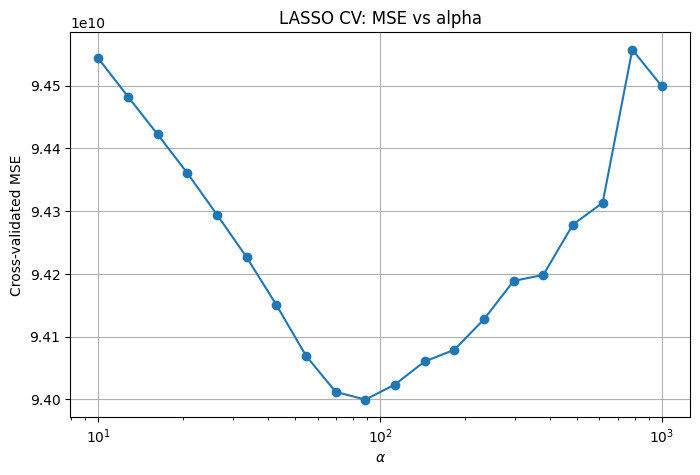

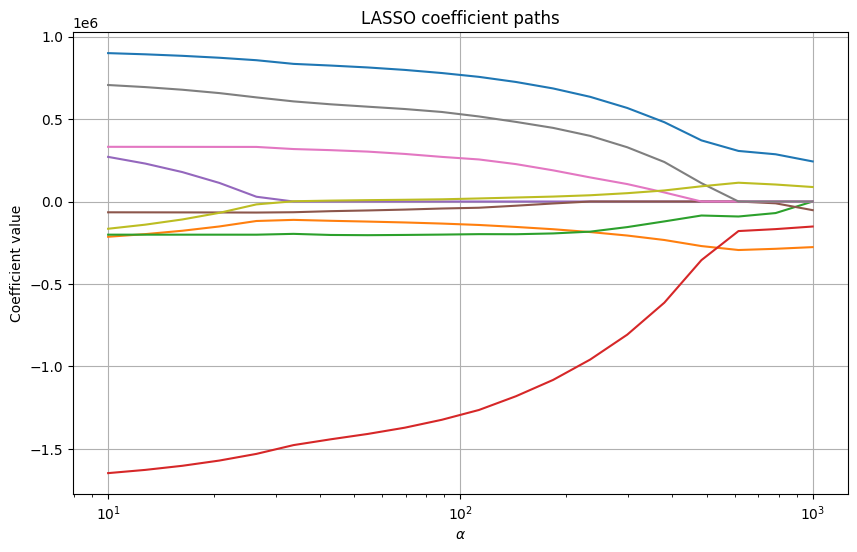

             Feature    LassoCoeff
3    Mileage_Run Age -1.370696e+06
0        Mileage_Run  8.170569e+05
6  Mileage_Run Age^2  5.263672e+05
5  Mileage_Run^2 Age  3.350559e+05
2      Mileage_Run^2 -2.450313e+05
1                Age -1.290883e+05
4      Mileage_Run^3 -4.691739e+04
7              Age^3  2.170756e+04
Proportion of coefficients set to zero: 0.111
             Feature   LinearCoeff    LassoCoeff
3    Mileage_Run Age -1.671212e+06 -1.370696e+06
0        Mileage_Run  9.117748e+05  8.170569e+05
6  Mileage_Run Age^2  7.167816e+05  5.263672e+05
5  Mileage_Run^2 Age  3.388195e+05  3.350559e+05
2      Mileage_Run^2 -2.072926e+05 -2.450313e+05
1                Age -2.481722e+05 -1.290883e+05
4      Mileage_Run^3 -6.514490e+04 -4.691739e+04
7              Age^3 -2.100379e+05  2.170756e+04


In [36]:
# QUESTION 1
df = pd.read_csv('data/cars_hw.csv')
df['Age'] = 2026 - df['Make_Year']
X = df[['Mileage_Run', 'Age']]
y = df['Price']

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
scaler = StandardScaler()
X_final = scaler.fit_transform(X_poly)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
print("Features:", feature_names)

# QUESTION 2
lr = LinearRegression()
lr.fit(X_final, y)

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_
})

print(coef_df)

# QUESTION 3
alphas = np.logspace(1, 3, 20)  # grid for alpha
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=5000)
lasso_cv.fit(X_final, y)

print("Best alpha (CV):", lasso_cv.alpha_)

# QUESTION 4
mse_path = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(8,5))
plt.plot(lasso_cv.alphas_, mse_path, marker='o')
plt.xscale('log')
plt.xlabel(r'$\alpha$')
plt.ylabel('Cross-validated MSE')
plt.title('LASSO CV: MSE vs alpha')
plt.grid(True)
plt.show()

# QUESTION 5
coefs = []
for a in alphas:
    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X_final, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10,6))
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=f'Feature {i}')
plt.xscale('log')
plt.xlabel(r'$\alpha$')
plt.ylabel('Coefficient value')
plt.title('LASSO coefficient paths')
plt.grid(True)
plt.show()

# QUESTION 6
lasso_coefs = lasso_cv.coef_
selected_idx = np.where(lasso_coefs != 0)[0]
selected_features = feature_names[selected_idx]
selected_coefs = lasso_coefs[selected_idx]

num_selected = len(selected_features)
total_features = X_final.shape[1]
num_zero = total_features - num_selected
prop_zero = num_zero / total_features

selected_summary = pd.DataFrame({
    'Feature': selected_features,
    'LassoCoeff': selected_coefs
}).sort_values(by='LassoCoeff', key=np.abs, ascending=False)

print(selected_summary)
print(f"Proportion of coefficients set to zero: {prop_zero:.3f}")

# QUESTION 7
linear_dict = dict(zip(feature_names, lr.coef_))

comparison_df = pd.DataFrame({
    'Feature': selected_features,
    'LinearCoeff': [linear_dict[f] for f in selected_features],
    'LassoCoeff': selected_coefs
}).sort_values(by='LassoCoeff', key=np.abs, ascending=False)

print(comparison_df)

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.

Done below.

2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?

There is some weirdness with how features are squared or cubed and their impact on the coefficient. For instance, age$^2$ is negative, but age$^3$ and age are positive. This indicates that the magnitude of a feature affects its impact on the overall predictiveness of the model.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(5,5,30)` to find the cost parameter)

Done below.

4. Plot the cross-validated MSE by $\alpha$.

Done below.

5. Plot the coefficient paths by $\alpha$.

Done below.

6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

The features that were actually selected are listed below, with the proportion of 0.586 features set to 0. Only anaemia and high blood pressure increase from  in magnitude from linear to LASSO. 6 features (ejection_fraction^3, serum_creatinine, serum_creatinine^3, ejection_fraction^2 serum_creatinine, high_blood_pressure, diabetes) change signs. In general, the signs for the LASSO coefficients seem to make more sense, as the less impactful features have zeroed coefficients to reduce their overall impact on the model, thus reducing overfitting and decreasing variance while allowing for an acceptable increase in bias.

Coefficients: [ 1.53915561 -2.19249366 -0.85358815 -3.67865393 -0.60091803  1.84156257
  3.43097646  2.67339362 -2.64704061  1.99313494  0.90802595 -0.69752151
 -0.08120632 -1.57766526  1.28409929 -1.25034105 -1.27004314  1.17947493
  0.07215578  0.00809253 -0.0707051  -0.00793437 -0.10268659  0.02615948
 -0.02725057  0.06490812  0.13244293  0.15607823  0.10145536]
                                   Feature  LinearCoeff
3                                    age^2    -3.678654
6                      ejection_fraction^2     3.430976
7       ejection_fraction serum_creatinine     2.673394
8                       serum_creatinine^2    -2.647041
1                        ejection_fraction    -2.192494
9                                    age^3     1.993135
5                     age serum_creatinine     1.841563
13  age ejection_fraction serum_creatinine    -1.577665
0                                      age     1.539156
14                  age serum_creatinine^2     1.284099
16    ejection_f

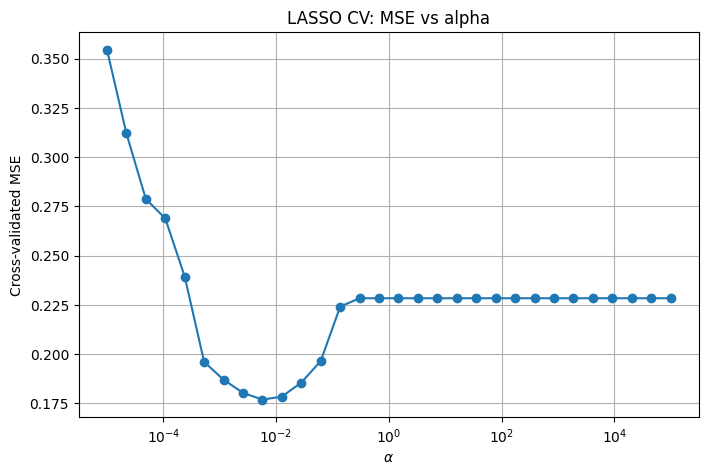

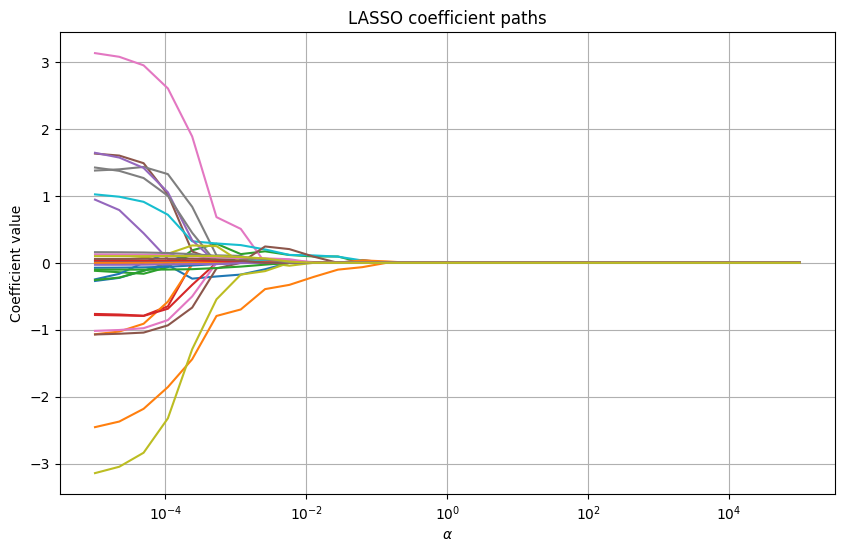

Best alpha (CV): 0.005736152510448681
Number of nonzero coefficients: 12
Selected feature indices: [ 1  2  9 15 16 18 19 20 21 26 27 28]
Number of selected features: 12
Proportion of coefficients set to zero: 0.5862068965517241
                                 Feature  LinearCoeff  LassoCoeff
0                      ejection_fraction    -2.192494   -0.329656
3                    ejection_fraction^3    -1.250341    0.204822
2                                  age^3     1.993135    0.117992
1                       serum_creatinine    -0.853588    0.116875
9           diabetes high_blood_pressure     0.132443    0.053968
5                     serum_creatinine^3     0.072156   -0.043266
4   ejection_fraction^2 serum_creatinine    -1.270043    0.032801
11           high_blood_pressure smoking     0.101455    0.017805
6                                anaemia     0.008093    0.014178
8                    high_blood_pressure    -0.007934    0.013608
10                      diabetes smoking     0

In [37]:
df= pd.read_csv('data/heart_failure_clinical_records_dataset.csv')
df.head()
df.columns

import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# QUESTION 1
cont_features = ['age', 'ejection_fraction', 'serum_creatinine']
X_cont = df[cont_features]

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)

scaler = StandardScaler()
X_cont_poly_scaled = scaler.fit_transform(X_cont_poly)

cat_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
X_cat = df[cat_features]

poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat_interact = poly_cat.fit_transform(X_cat)

X_final = np.hstack([X_cont_poly_scaled, X_cat_interact])

# QUESTION 2
y = df['DEATH_EVENT'].values

lr = LinearRegression()
lr.fit(X_final, y)

coeffs = lr.coef_
print("Coefficients:", coeffs)

cont_features = ['age', 'ejection_fraction', 'serum_creatinine']
poly_cont_feature_names = poly_cont.get_feature_names_out(cont_features)

# 2. Categorical features (interaction terms)
cat_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
poly_cat_feature_names = poly_cat.get_feature_names_out(cat_features)

# 3. Combine all feature names (order matches X_final)
all_feature_names = np.hstack([poly_cont_feature_names, poly_cat_feature_names])

# 4. Create a dataframe mapping features to linear regression coefficients
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'LinearCoeff': coeffs
})

# 5. Optionally, sort by absolute coefficient magnitude
coef_df['AbsCoeff'] = np.abs(coef_df['LinearCoeff'])
coef_df_sorted = coef_df.sort_values(by='AbsCoeff', ascending=False).drop(columns='AbsCoeff')

print(coef_df_sorted)

# QUESTION 3

alphas = np.logspace(-5, 5, 30)  # small to large penalty

lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=5000)
lasso_cv.fit(X_final, y)

mse_path = np.mean(lasso_cv.mse_path_, axis=1)

# QUESTION 4
plt.figure(figsize=(8,5))
plt.plot(lasso_cv.alphas_, mse_path, marker='o')
plt.xscale('log')
plt.xlabel(r'$\alpha$')
plt.ylabel('Cross-validated MSE')
plt.title('LASSO CV: MSE vs alpha')
plt.grid(True)
plt.show()

coefs = []
for a in alphas:
    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X_final, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

# QUESTION 5
plt.figure(figsize=(10,6))
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=f'Feature {i}')
plt.xscale('log')
plt.xlabel(r'$\alpha$')
plt.ylabel('Coefficient value')
plt.title('LASSO coefficient paths')
plt.grid(True)
plt.show()

print("Best alpha (CV):", lasso_cv.alpha_)
print("Number of nonzero coefficients:", np.sum(lasso_cv.coef_ != 0))

# QUESTION 6
selected_features_idx = np.where(lasso_cv.coef_ != 0)[0]
num_selected = len(selected_features_idx)
print("Selected feature indices:", selected_features_idx)
print("Number of selected features:", num_selected)

total_features = X_final.shape[1]
num_zero = total_features - num_selected
print("Proportion of coefficients set to zero:", num_zero / total_features)

lr = LinearRegression().fit(X_final, y)
lr_coefs = lr.coef_

lasso_coefs = lasso_cv.coef_

coef_comparison = pd.DataFrame({
    "Linear": lr_coefs,
    "LASSO": lasso_coefs
})

cont_feature_names = poly_cont.get_feature_names_out(cont_features)
cat_feature_names = poly_cat.get_feature_names_out(cat_features)
all_feature_names = np.hstack([cont_feature_names, cat_feature_names])
selected_features = all_feature_names[selected_features_idx]
selected_coefs = lasso_coefs[selected_features_idx]

linear_dict = dict(zip(all_feature_names, lr_coefs))

comparison_df = pd.DataFrame({
    "Feature": selected_features,
    "LinearCoeff": [linear_dict[f] for f in selected_features],
    "LassoCoeff": selected_coefs
}).sort_values(by="LassoCoeff", key=np.abs, ascending=False)

print(comparison_df)

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

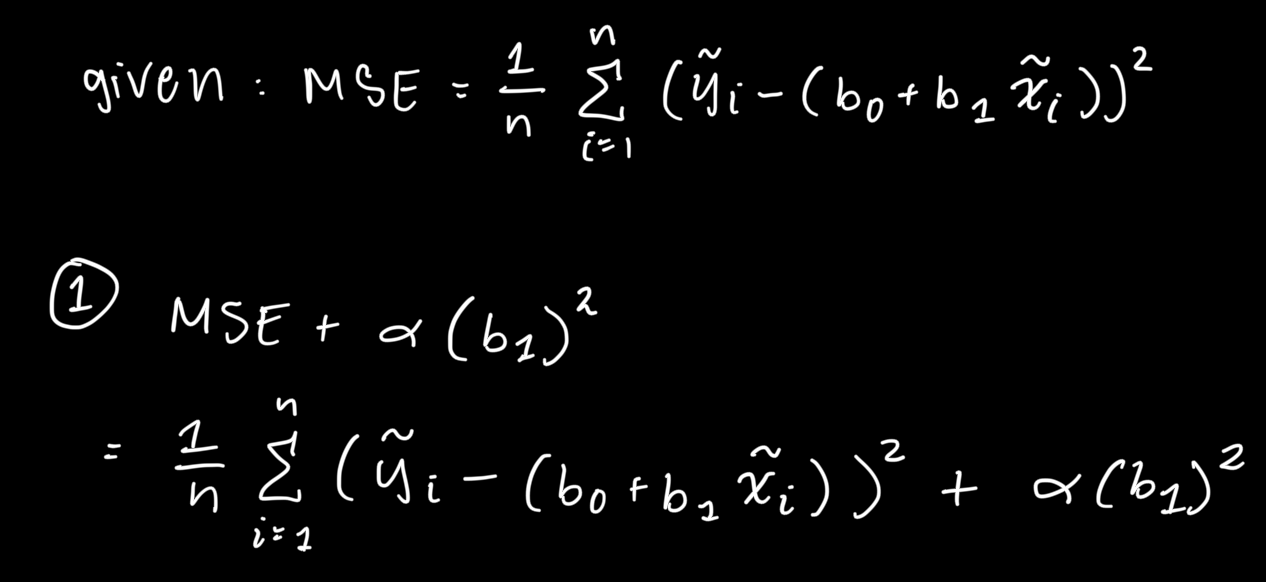

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

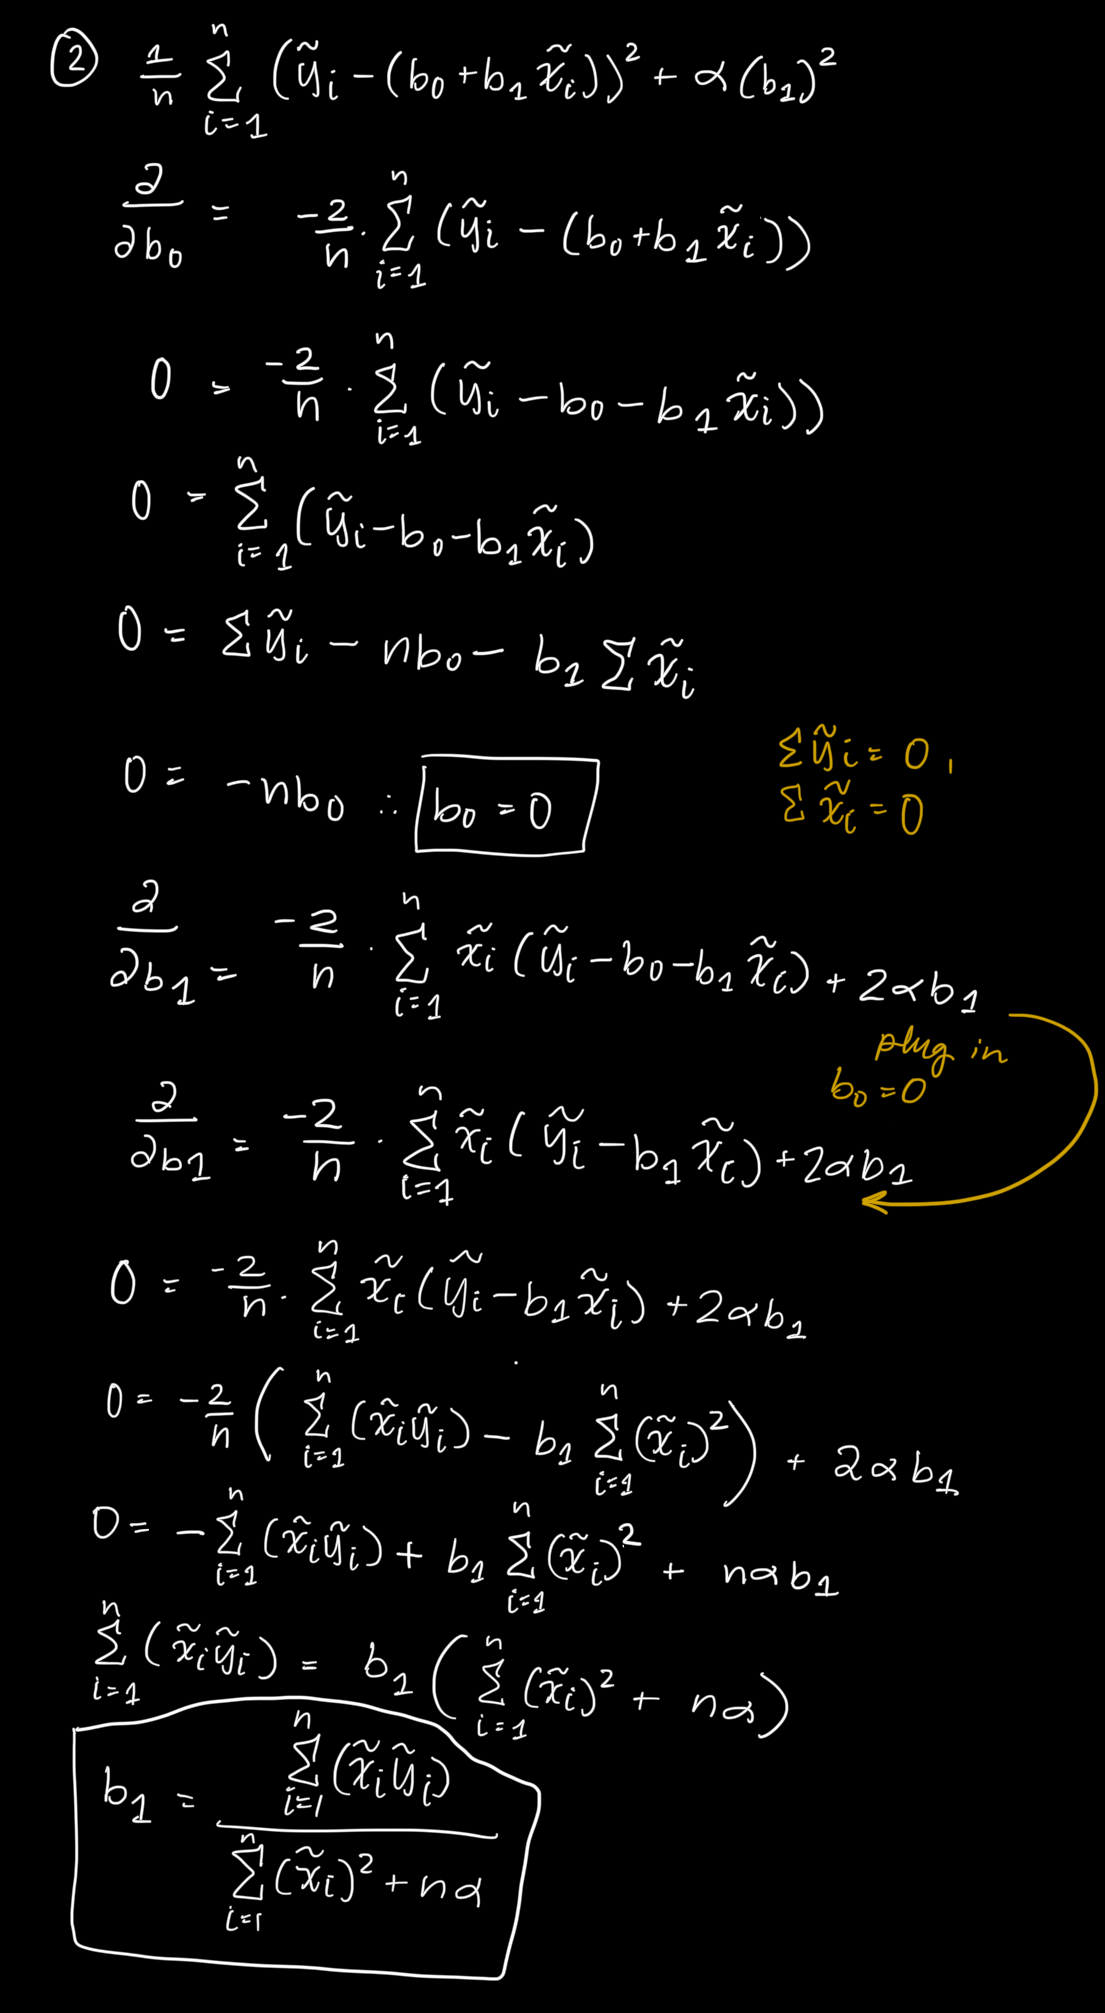

3. How does increasing $\alpha$ change the slope coefficient?

With the increase in $\alpha$, the denominator above increases, so $b_1$ approaches 0. As a result, a larger penalty produces a flatter slope and less sensitivities to x.

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

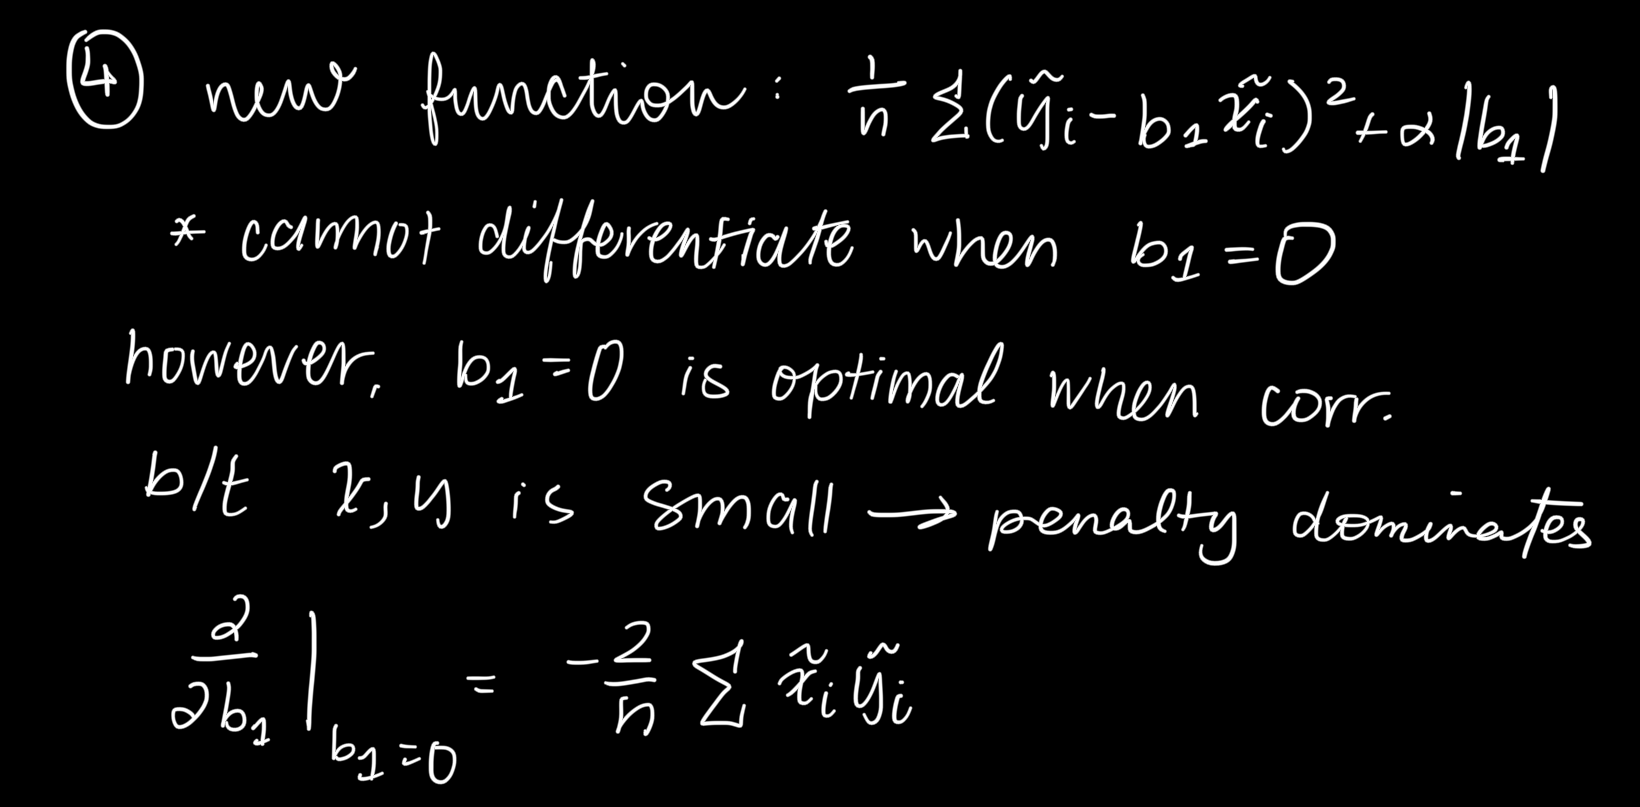
